<a href="https://colab.research.google.com/github/nahmxp/rl-for-data-scientists/blob/main/notebooks/chapter_04_policies_values/04_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 — Exercises## Policies, Values & Bellman Equations

### Environment Setup
Before solving the exercises, we need to define the GridWorld environment. This is a 4x4 grid where the top-left and bottom-right corners are terminal states. Each movement incurs a reward of -1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class GridWorld:
    def __init__(self, size=4):
        self.size = size
        self.states = [(i, j) for i in range(size) for j in range(size)]
        self.terminal_states = [(0, 0), (size-1, size-1)]
        self.actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']
        self.action_map = {
            'UP': (-1, 0), 'DOWN': (1, 0), 'LEFT': (0, -1), 'RIGHT': (0, 1)
        }

    def step(self, state, action):
        if state in self.terminal_states:
            return state, 0

        move = self.action_map[action]
        next_state = (max(0, min(self.size - 1, state[0] + move[0])),
                      max(0, min(self.size - 1, state[1] + move[1])))
        return next_state, -1

env = GridWorld()

### Exercise 4.1: Implement policy iterationUsing the GridWorld from the concept notebook, implement full **policy iteration** (not just evaluation):1. Start with a random policy2. Evaluate the policy (compute V^π)3. Improve the policy (greedy from V^π)4. Repeat until the policy stops changingHow many iterations until convergence?

In [ ]:
# Exercise 4.1: Policy iteration
import numpy as np


In [2]:
def policy_evaluation(policy, env, gamma=1.0, theta=1e-6):
    """Computes the state-value function V for a given policy."""
    V = np.zeros((env.size, env.size))
    while True:
        delta = 0
        for r in range(env.size):
            for c in range(env.size):
                if (r, c) in env.terminal_states: continue

                v = V[r, c]
                new_v = 0
                for action, prob in enumerate(policy[r, c]):
                    next_s, reward = env.step((r, c), env.actions[action])
                    new_v += prob * (reward + gamma * V[next_s])

                V[r, c] = new_v
                delta = max(delta, abs(v - new_v))
        if delta < theta: break
    return V

def policy_improvement(V, env, gamma=1.0):
    """Updates the policy to be greedy with respect to V."""
    policy_stable = True
    new_policy = np.zeros((env.size, env.size, len(env.actions)))

    for r in range(env.size):
        for c in range(env.size):
            if (r, c) in env.terminal_states: continue

            action_values = []
            for action in env.actions:
                next_s, reward = env.step((r, c), action)
                action_values.append(reward + gamma * V[next_s])

            best_action = np.argmax(action_values)
            new_policy[r, c, best_action] = 1.0
    return new_policy

# Main Policy Iteration Loop
policy = np.ones((env.size, env.size, len(env.actions))) / len(env.actions)
iterations = 0
while True:
    iterations += 1
    V = policy_evaluation(policy, env)
    new_policy = policy_improvement(V, env)

    if np.array_equal(new_policy, policy):
        break
    policy = new_policy

print(f"Policy Iteration converged in {iterations} iterations.")
print("Final Value Function:")
display(V)

Policy Iteration converged in 3 iterations.
Final Value Function:


array([[ 0., -1., -2., -3.],
       [-1., -2., -3., -2.],
       [-2., -3., -2., -1.],
       [-3., -2., -1.,  0.]])

### Exercise 4.2: Compare V^π for different γ valuesCompute V^π (random policy) for γ ∈ {0.5, 0.7, 0.9, 0.99} and visualise all four heat maps side by side. How does γ affect the value of cells far from the goal?

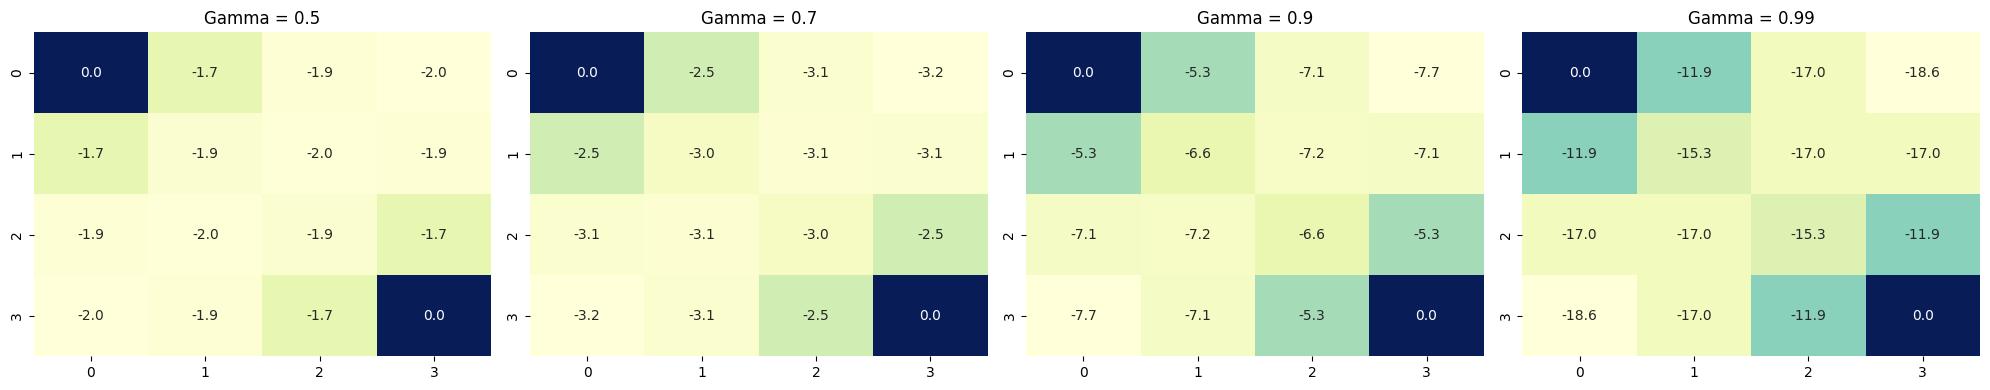

In [3]:
import seaborn as sns

gammas = [0.5, 0.7, 0.9, 0.99]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Uniform random policy
random_policy = np.ones((env.size, env.size, len(env.actions))) / len(env.actions)

for i, g in enumerate(gammas):
    V_g = policy_evaluation(random_policy, env, gamma=g)
    sns.heatmap(V_g, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], cbar=False)
    axes[i].set_title(f"Gamma = {g}")

plt.tight_layout()
plt.show()

### Exercise 4.3: The Q-functionCompute Q^π(s, a) for the random policy. Show that:- V^π(s) = Σ_a π(a|s) Q^π(s,a) [value = average of Q over actions]- The greedy policy picks a* = argmax_a Q^π(s,a)

In [4]:
def compute_q_function(V, env, gamma=1.0):
    """Computes the Q-function Q(s, a) for all s, a."""
    Q = np.zeros((env.size, env.size, len(env.actions)))
    for r in range(env.size):
        for c in range(env.size):
            if (r, c) in env.terminal_states: continue
            for i, action in enumerate(env.actions):
                next_s, reward = env.step((r, c), action)
                Q[r, c, i] = reward + gamma * V[next_s]
    return Q

# Compute V for random policy
random_policy = np.ones((env.size, env.size, len(env.actions))) / len(env.actions)
V_random = policy_evaluation(random_policy, env)
Q_random = compute_q_function(V_random, env)

# Verification: V(s) should be average of Q(s, a)
V_from_Q = np.sum(random_policy * Q_random, axis=2)

print("Verification: Difference between V and average Q (should be near 0):")
print(np.max(np.abs(V_random - V_from_Q)))

print("\nExample Q-values for state (1,1):")
for i, action in enumerate(env.actions):
    print(f"{action}: {Q_random[1, 1, i]:.2f}")

Verification: Difference between V and average Q (should be near 0):
6.812280233248202e-07

Example Q-values for state (1,1):
UP: -15.00
DOWN: -21.00
LEFT: -15.00
RIGHT: -21.00
